In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

# Tutorial to Least Squares and Recursive Least Squares applied to tracking runner's performance

## Runner Performance Modeling

Imagine a scenario where a runner trains daily for a 100m run. During training, he uses a sophisticated timer to keep a very accurate true time. He wants to know his pace over the 100m sprint during competition. However, on competition day, he will not have this sophisticated timer, so 3 coaches volunteered to record his times for that day. 1 coach will record times between distances (0 to 50) meters another between distances (50 to 100) meters, and the last at 100 meters.

We want to estimate his pace on competition day, knowing that runners typically accelerate in the first half and maintain speed in the second half.

Let's model the observed time ($t_{observed,j}$) measured by coach $j$ as:

$$t_{observed,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j$$

Where:
*   $\theta_1$: The model **parameter** representing the runner's pace (seconds per meter) in segment 1 (0-50m).
*   $\theta_2$: The model **parameter** representing the runner's pace (seconds per meter) in segment 2 (50-100m).
*   $d_{1,j} = \min(d_j, 50)$: The **known distance** the runner traveled in segment 1 when passing coach $j$.
*   $d_{2,j} = \max(0, d_j - 50)$: The **known distance** the runner traveled in segment 2 when passing coach $j$.
*   $\epsilon_j$: Coach $j$'s measurement error from timing imprecision and other unmodeled factors.

By estimating $\theta_1$ and $\theta_2$ from the three coaches' noisy time measurements, we can reconstruct the runner's true pace profile on competition day.
Because this equation is linear with respect to the model parameters, this problem can be formulated as a linear system suitable for Least Squares estimation.

## Introduction to Least Squares

### Least Squares Background and Formulation

Least Squares (LS) is a powerful and widely used optimization technique to find the 'best-fit' line or curve for a dataset. It achieves this by minimizing the sum of the squared differences (also known as residuals) between the observed data points and the values predicted by our model. The core idea is that smaller squared errors mean a better fit of our model to the data.

Mathematically, for a linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$, where we want to find the unknown parameter vector $\mathbf{x}$, the Least Squares solution $\hat{\mathbf{x}}$ is defined as the $\mathbf{x}$ that minimizes the following objective function:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2 $$

This optimization problem has a closed-form solution, which is derived by taking the derivative of the objective function with respect to $\mathbf{x}$ and setting it to zero. The resulting solution is the famous Normal Equations:

$$ \mathbf{A}^T \mathbf{A} \hat{\mathbf{x}} = \mathbf{A}^T \mathbf{b} $$

Solving for $\hat{\mathbf{x}}$ gives us the Least Squares estimate:

$$ \hat{\mathbf{x}} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

This solution provides the Moore-Penrose pseudo-inverse of $\mathbf{A}$, effectively giving us the $\mathbf{x}$ that best satisfies the overdetermined system of equations.

### Potential LS reformulations (Beyond this tutorial's scope)

LS is a powerful technique that can be reformulated to fit more accurate estimation for a given problem. However, in this tutorial, we will only discuss extentions towards recursive least squares. In practice, model formulation and good data collection/processing are two sides of the same coin for good estimation (results). Below are some ways to reformulate the model to estimate with least squares, serving as a roadmap to those with different problems:

*   **Modeling with nonlinear features:**
  \
  Our piecewise linear model provides a simple approximation of the runner's acceleration. However, a smoother and more realistic model could use **polynomial features** to capture continuous pace changes:
  $$
  t(d_j) = \theta_0 \cdot d_j + \theta_1 \cdot \frac{d_j^2}{2} + \theta_2 \cdot \frac{d_j^3}{3} + \epsilon_j
  $$
  where the pace function $\theta(d) = \theta_0 + \theta_1 d + \theta_2 d^2$ varies smoothly with distance. The features $d_j$, $d_j^2$, and $d_j^3$ are **nonlinear transformations** of the coach positions, but the model remains **linear in the parameters** $(\theta_0, \theta_1, \theta_2)$ and can be solved using standard least squares. This approach captures smooth acceleration and deceleration without requiring nonlinear optimization, providing a middle ground between the simplicity of piecewise linear models and the complexity of fully nonlinear models.


*   **Modeling with nonlinear parameters:**
  \
  Our piecewise linear model provides a simple approximation of the runner's acceleration. However, a more accurate nonlinear model would be the **exponential pace model**:
  $$
  \theta(d) = \theta_{ss} + (\theta_0 - \theta_{ss})e^{-\theta_r d}
  $$
  where the runner smoothly transitions from initial pace $\theta_0$ to steady-state pace $\theta_{ss}$ with rate $\lambda$. The cumulative time at distance $d_j$ is:
  $$
  t(d_j) = \theta_{ss} \cdot d_j + \frac{\theta_0 - \theta_{ss}}{\theta_r}(1 - e^{-\theta_r d_j})
  $$
  This model is **nonlinear** in the parameters due to $\lambda$ appearing in both the exponent and denominator, requiring iterative nonlinear estimation methods.
  \
  \
  Alternatively, we can apply least squares to a **linearized differential equation** formulation. The exponential model satisfies:
  $$
  \frac{d\theta}{dd} = -\theta_r(\theta - \theta_{ss})
  $$
  \
  This reparameterization onto the pace rate provides a physics-based linear approach, though it introduces additional noise through differentiation. For best accuracy with smooth nonlinear models, direct nonlinear least squares estimation is preferred.

*   **Estimating coach-specific timing bias**
  \
  Suppose the primary source of noise in the observed times comes from how each coach captures the split time at their position. We model this by introducing a coach-specific bias term:
  \
  $$
  t_{obs,j} = d_j^{(1)} \cdot \theta_1 + d_j^{(2)} \cdot \theta_2 + b_j + \epsilon_j
  $$
  \
  where $b_j$ captures the consistent timing bias associated with coach $j$ (e.g., one coach consistently starts their stopwatch early, another late). However, introducing a separate bias parameter for each coach often leads to an underdetermined system. With 4 coaches, we would have 5 parameters $$\theta_1, \theta_2, b_1, b_2, b_3$$ but only 3 measurements from a single run. This requires richer data collection, such as the runner performing multiple runs under different conditions, or having coaches measure multiple runners with known true times to calibrate their biases.

*   **Non-i.i.d. (independent and identically distributed) noise variance**
  \
  Standard least squares is the optimal estimator when measurement noise is Gaussian, independent, and identically distributed across all observations. However, we should expect the coaches to have different accuracies in their timing measurements:
  \
  -- Coach 1 might have faster reaction time (lower variance)
  \
  -- Coach 2 might be less experienced (higher variance)
  \
  When noise variances differ across coaches but are uncorrelated(heteroscedastic noise), **weighted least squares** is more appropriate, described briefly in later sections on this tutorial.

*   **Regularized Least Squares (ridge or lasso)**

  When using high-order polynomial features or many parameters, the system can overfit to noise or become unstable due to multicollinearity (e.g., $d^2$ and $d^3$ are highly correlated). Regularization adds a penalty to the least squares objective function to shrink parameter estimates and improve generalization.


### Formulating a linear system (Ax=B)

To apply Least squares, we transform our runner timing model into the standard linear form. This is called our observation model:

For coach $j$ at position $d_j$:

$$
t_{obs,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j
$$

Where:
- $d_{1,j} = \min(d_j, 50)$ = distance in segment 1 (0-50m)
- $d_{2,j} = \max(0, d_j - 50)$ = distance in segment 2 (50-100m)

The above system of equations map to a matrix form:

$$
\mathbf{t}_{obs} = \mathbf{A}\boldsymbol{\theta} + \boldsymbol{\epsilon}
$$

Expanded:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
d_{1,1} & d_{2,1} \\
d_{1,2} & d_{2,2} \\
d_{1,3} & d_{2,3}
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$
\
For example, with 3 Coaches at 25m, 75m, and 100m:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
25 & 0 \\
50 & 25 \\
50 & 50
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$

#### Python imports
Prior to beginning this jupyter-notebook tutorial, we can include some python imports.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
np.random.seed(42)

# True underlying parameters for the runner's performance model (theta_1 for 0-50m, theta_2 for 50-100m)
true_theta1 = 0.11 # seconds per meter in segment 1 (0-50m)
true_theta2 = 0.10 # seconds per meter in segment 2 (50-100m)

# Coach positions for measurements
coach_positions = np.array([25, 75, 100]) # Example: Coach at 25m, 75m, 100m

num_runs_per_day = 1 # Each day has one set of measurements from the coaches
num_days_to_simulate = 50 # Simulate data for 50 days

# --- Generate daily simulated data ---
def generate_daily_data(day_number, true_t1, true_t2, coach_pos):
    distances_seg1 = []
    distances_seg2 = []
    observed_times = []

    for d_j in coach_pos:
        d1_j = min(d_j, 50)
        d2_j = max(0, d_j - 50)

        # Simulate measurement noise
        noise = np.random.normal(0, 0.05) # Small measurement noise in seconds

        # True time = d1 * theta1 + d2 * theta2 + noise
        observed_time = d1_j * true_t1 + d2_j * true_t2 + noise

        distances_seg1.append(d1_j)
        distances_seg2.append(d2_j)
        observed_times.append(observed_time)

    df_day = pd.DataFrame({
        'day': day_number,
        'distance_seg1': distances_seg1,
        'distance_seg2': distances_seg2,
        'observed_time': observed_times
    })
    return df_day

# Generate data for multiple days
all_daily_data = []
for day in range(1, num_days_to_simulate + 1):
    # For each run (day), we get observations from all coaches
    # The num_runs_per_day is now implicitly handled by the number of coach_positions
    # If we wanted multiple "runs" per day, we'd need another loop here
    all_daily_data.append(generate_daily_data(day, true_theta1, true_theta2, coach_positions))

df_all_data = pd.concat(all_daily_data, ignore_index=True)

print(f"Simulated Data for {num_days_to_simulate} Days (first 5 rows):")
display(df_all_data.head())

# --- Construct A and b for a given DataFrame ---
def construct_A_b(df):
    num_params = 2 # theta_1, theta_2
    A = np.zeros((len(df), num_params))
    b = df['observed_time'].values.reshape(-1, 1)

    for local_idx, (original_idx, row) in enumerate(df.iterrows()):
        A[local_idx, 0] = row['distance_seg1'] # Coefficient for theta_1
        A[local_idx, 1] = row['distance_seg2'] # Coefficient for theta_2

    # Define the parameter vector 'x' for context
    param_names = ['theta_1', 'theta_2']

    return A, b, param_names

# Example for Day 1
df_day1 = df_all_data[df_all_data['day'] == 1]
A_day1, b_day1, param_names = construct_A_b(df_day1)

print("\nDesign Matrix A (Day 1, first 3 rows):\n", A_day1[:3])
print("\nObservation Vector b (Day 1, first 3 rows):\n", b_day1[:3].flatten())
print("\nParameter Names in x:\n", param_names)

# True parameters vector for comparison
true_params_vec = np.array([
    true_theta1,
    true_theta2
]).reshape(-1, 1)

# Also update the `true_params` for Day 1 LS output
true_params = np.array([
    true_theta1,
    true_theta2
]).reshape(-1, 1)

Simulated Data for 50 Days (first 5 rows):


,day,distance_seg1,distance_seg2,observed_time
0,1,25,0,2.774836
1,1,50,25,7.993087
2,1,50,50,10.532384
3,2,25,0,2.826151
4,2,50,25,7.988292



Design Matrix A (Day 1, first 3 rows):
 [[25.  0.]
 [50. 25.]
 [50. 50.]]

Observation Vector b (Day 1, first 3 rows):
 [ 2.77483571  7.99308678 10.53238443]

Parameter Names in x:
 ['theta_1', 'theta_2']


### Least Squares for Runner Timing

Given our runner timing problem formulated as $\mathbf{A}\mathbf{x}=\mathbf{b}$, we can directly apply the Least Squares solution to estimate the runner's speed at each distance band for each day:

$$ \mathbf{x}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$


In [33]:
x_ls = np.linalg.inv(A_day1.T @ A_day1) @ A_day1.T @ b_day1

print("Least Squares Estimates for Day 1:")
for i, param in enumerate(param_names):
    print(f"{param}: {x_ls[i, 0]:.4f}")

print("\nTrue Parameters:")
print(f"theta_1: {true_params_vec[0,0]:.4f}")
print(f"theta_2: {true_params_vec[1,0]:.4f}")

# Calculate estimation error for Day 1
# true_params_vec is now globally defined from the simulation setup.
error_ls = np.linalg.norm(x_ls - true_params_vec)
print(f"\nLS Estimation Error (Day 1): {error_ls:.4f}")

Least Squares Estimates for Day 1:
theta_1: 0.1101
theta_2: 0.1003

True Parameters:
theta_1: 0.1100
theta_2: 0.1000

LS Estimation Error (Day 1): 0.0003


### Interpretation of Day 1 LS Results

The Least Squares estimates for Day 1 show a reasonable estimation error, indicating that with more observations than parameters, the system is well-determined. For Day 1, we have `num_runs_per_day = 5` observations and are estimating `num_params = 2` parameters (1 baseline, 1 wind effect). This makes the system overdetermined, allowing for a stable LS solution. While the error is not zero, it's a significant improvement compared to an underdetermined system.

This outcome reinforces the necessity of having sufficient data to reliably estimate parameters, which is why we move to Batch Least Squares and Recursive Least Squares. These methods accumulate observations over time, providing a sufficiently rich dataset for stable and accurate parameter estimation.

## Batch Least Squares for Runner Timing

While the single-day LS provides an immediate estimate, it's often noisy and inaccurate due to limited data. What if we want to use *all* the past data to get a more robust estimate of the runner's baseline ability and wind effect?

This is where **Batch Least Squares** comes in. The idea is to collect all available observations up to a certain point in time and then process them together to obtain a single, comprehensive estimate. This approach assumes that the underlying parameters (runner's baseline, wind effect) are relatively constant over the batch period.

Suppose we collect $K$ observations (timed runs) over several days. Each observation $k$ (which is a single row in our `A` matrix and a single entry in `b`) contributes to a system of equations:

$$ t_k = t_{baseline} + w_{wind} \cdot v_{wind,k} + \epsilon_k $$

Our goal then becomes to solve this optimization problem, minimizing the sum of squared residuals across *all* $K$ observations:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 $$

Here, $\mathbf{A}_k$ represents the row of the design matrix corresponding to the $k$-th observation, and $\mathbf{b}_k$ is the $k$-th observed time.

### Batch Least Squares Linear Algebra

The sum of squared norms can be equivalently written using 'stacked' matrices:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

Where $\mathbf{A}_{stack}$ and $\mathbf{b}_{stack}$ are formed by vertically concatenating all individual observation matrices and vectors:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Each $\mathbf{A}_k$ is a $1 \times N$ row vector (where $N$ is the number of parameters, e.g., baseline, wind effect), and $\mathbf{b}_k$ is a $1 \times 1$ scalar (the observed time).
Thus, if we have $K$ observations:

*   $\mathbf{A}_{stack}$ will have dimensions $K \times N$.
*   $\mathbf{b}_{stack}$ will have dimensions $K \times 1$.

The number of parameters $N$ in our runner timing example is $1$ (baseline) + $1$ (wind effect).

This transformation converts the sum of individual least squares problems into a single, larger least squares problem, which can then be solved using the standard Normal Equations.

#### Proof of Equivalence for Sum of Squared Norms and Stacked Matrices

Let's clarify why the expression $\sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2$ is equivalent to $\left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2$.

Recall that the squared Euclidean norm of a vector $\mathbf{v}$ is given by $ \|\mathbf{v}\|_2^2 = \mathbf{v}^T \mathbf{v} = \sum v_i^2 $. In our case, each term $(\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)$ is a scalar, representing the residual $e_k$ for the $k$-th observation. So, the sum of squared norms can be written as:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \sum_{k=1}^{K} (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

Now, let's consider the stacked matrices:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

When we compute the product $\mathbf{A}_{stack} \mathbf{x}$, we get a column vector:

$$ \mathbf{A}_{stack} \mathbf{x} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} $$

The residual vector for the stacked system is then:

$$ \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} - \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} - \mathbf{b}_1 \\ \mathbf{A}_2 \mathbf{x} - \mathbf{b}_2 \\ \vdots \\ \mathbf{A}_K \mathbf{x} - \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} e_1 \\ e_2 \\ \vdots \\ e_K \end{bmatrix} $$

Let's call this stacked residual vector $\mathbf{e}_{stacked}$. Taking its squared Euclidean norm, we get:

$$ \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 = \|\mathbf{e}_{stacked}\|_2^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

By comparing the two final expressions, we can clearly see that:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

This equivalence is fundamental for reformulating multiple individual least squares problems into a single, larger batch problem.

Which then results in the familiar LS formulation for the stacked system:

$$ \hat{\mathbf{x}} = (\mathbf{A}_{stack}^T \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{b}_{stack} $$

Alternatively, this can also be expressed as the sum of individual contributions:

$$ \hat{\mathbf{x}} = \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k \right)^{-1} \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k \right) $$

Where:
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k$ is an $N \times N$ matrix.
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k$ is an $N \times 1$ vector.

This formulation is crucial because it highlights how each new observation contributes to updating the overall sum, which will be fundamental for understanding Recursive Least Squares later.

In [23]:
class BatchedLeastSQ:
    def __init__(self, name='BatchedleastSQ_runner', lambda_=1.0):
        self.name = name
        self.lambda_ = lambda_

        # Model now has theta_1 and theta_2
        self.num_params = 2 # theta_1, theta_2
        self.param_names = ['theta_1', 'theta_2'] # Updated parameter names

        self.A_mat_st = np.empty((0, self.num_params))
        self.b_vec_st = np.empty((0, 1))

        self.estimates_history = []
        self.error_history = []

        # Initialize S and q for recursive weighted sum
        self._S_accum = np.zeros((self.num_params, self.num_params)) # A.T @ A
        self._q_accum = np.zeros((self.num_params, 1)) # A.T @ b

    def update_batch(self, A_new, b_new, true_params):
        # Apply forgetting factor to previous accumulations
        self._S_accum = self.lambda_ * self._S_accum
        self._q_accum = self.lambda_ * self._q_accum

        # Add current data's contribution
        self._S_accum += A_new.T @ A_new
        self._q_accum += A_new.T @ b_new

        # For display and historical purposes, we still concatenate A and b
        # This is primarily for conceptual understanding of 'stacked' matrices
        # but the actual calculation uses _S_accum and _q_accum for EWLS
        # Note: A_mat_st and b_vec_st are not strictly necessary for the EWLS calculation itself
        # but are kept for conceptual clarity of the 'stacked' approach in batch processing.
        self.A_mat_st = np.concatenate((self.A_mat_st * np.sqrt(self.lambda_), A_new), axis=0)
        self.b_vec_st = np.concatenate((self.b_vec_st * np.sqrt(self.lambda_), b_new), axis=0)

        # Perform EWLS estimation if enough data
        # Check for invertibility of _S_accum (which is A.T @ A for the weighted system)
        # It is also important that A_new has at least self.num_params rows to ensure A.T@A is full rank
        if np.linalg.det(self._S_accum) != 0 and self.A_mat_st.shape[0] >= self.num_params:
            try:
                x_batch = np.linalg.inv(self._S_accum) @ self._q_accum

                self.estimates_history.append(x_batch)
                # Calculate error
                error = np.linalg.norm(x_batch - true_params)
                self.error_history.append(error)
            except np.linalg.LinAlgError as e:
                print(f"Batch LS estimation failed: {e}. Skipping this update.")
                self.estimates_history.append(np.full((self.num_params, 1), np.nan))
                self.error_history.append(np.nan)
        else:
            # Not enough observations or _S_accum is singular
            self.estimates_history.append(np.full((self.num_params, 1), np.nan))
            self.error_history.append(np.nan)

    def get_last_estimate(self):
        if self.estimates_history:
            return self.estimates_history[-1]
        return None

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)

## Weighted Least Squares (WLS)

In our runner timing simulation, we've assumed that all measurements are equally reliable. However, in a real-world scenario, this might not be true. For instance, some measurement devices or conditions might lead to lower or higher variance in measurements. When the measurement noise has unequal variances, the standard Ordinary Least Squares (OLS) estimator is no longer the most efficient. This is where **Weighted Least Squares (WLS)** becomes necessary.

### Why WLS?

OLS is optimal (specifically, it's the Best Linear Unbiased Estimator, or BLUE) when the measurement errors are uncorrelated and have equal variance (i.e., homoscedasticity). If the variances are unequal (heteroscedasticity), OLS estimates are still unbiased, but they are no longer efficient, meaning there exists another linear unbiased estimator with smaller variance. WLS accounts for these unequal variances by assigning different 'weights' to each observation based on its reliability.

### WLS Formulation

The WLS objective function minimizes the sum of squared weighted residuals:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} w_k (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 $$

Or, in matrix form, it minimizes:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is a diagonal matrix containing the weights $w_k$ on its diagonal. The optimal choice for $\mathbf{W}$ is the inverse of the covariance matrix of the measurement noise, $\mathbf{R}^{-1}$. If the errors are uncorrelated (which is a reasonable assumption for independent measurements), $\mathbf{R}$ is a diagonal matrix, and thus $\mathbf{W}$ is also a diagonal matrix, where each diagonal element $w_k$ is inversely proportional to the variance of the $k$-th measurement noise ($\sigma_k^2$), i.e., $w_k = 1/\sigma_k^2$.

Setting the derivative with respect to $\mathbf{x}$ to zero yields the WLS solution:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}^T \mathbf{W} \mathbf{A})^{-1} \mathbf{A}^T \mathbf{W} \mathbf{b} $$

In our runner timing scenario, if some measurements are known to be less precise (higher variance) than others, we would assign a smaller weight to those less reliable observations and a larger weight to more reliable ones. This effectively reduces the influence of less reliable data points on the overall parameter estimates.

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations within a batch least squares framework. This means that recent data points contribute more significantly to the current parameter estimate, while older data points are progressively down-weighted.

### How `lambda` Acts as a Weight: A More Formal View

Let's consider the objective function for WLS:

$$ \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is the weight matrix. In EWLS, we want to construct $\mathbf{W}$ such that it gives more importance to recent data. Suppose we have $K$ observations collected up to the current time, where observation $i$ occurred at time $i$. For the current time $K$, we define the weight for the $i$-th observation as $w_i = \lambda^{K-i}$. Here, $\lambda$ is the forgetting factor, $0 < \lambda \le 1$.

The stacked design matrix $\mathbf{A}_{stack}$ and observation vector $\mathbf{b}_{stack}$ are:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Where each $\mathbf{A}_i$ is a $1 \times N$ row vector (representing the $i$-th observation) and $\mathbf{b}_i$ is a scalar.

The weight matrix $\mathbf{W}$ for the stacked system is a diagonal matrix, where each diagonal element corresponds to the weight of the respective observation:

$$ \mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_K) = \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} $$

This diagonal matrix $\mathbf{W}$ is directly incorporated into the WLS solution.

### EWLS Formulation for Batch Processing: The Matrix Math

When applying EWLS to a batch of data collected over time, we need to show how the `lambda` terms explicitly weight the contributions of individual observations in the accumulators for $\mathbf{A}^T \mathbf{A}$ and $\mathbf{A}^T \mathbf{b}$.

From the WLS solution, we have:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack} $$

Let's expand the terms $\mathbf{S}_K = \mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack}$:

$$ \mathbf{S}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} $$

First, multiply $\mathbf{W} \mathbf{A}_{stack}$:

$$ \mathbf{W} \mathbf{A}_{stack} = \begin{bmatrix}
\lambda^{K-1} \mathbf{A}_1 \\
\lambda^{K-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_K
\end{bmatrix} $$

Then, multiply $\mathbf{A}_{stack}^T$ by this result:

$$ \mathbf{S}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} \mathbf{A}_1 \\
\lambda^{K-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_K
\end{bmatrix} = \lambda^{K-1} \mathbf{A}_1^T \mathbf{A}_1 + \lambda^{K-2} \mathbf{A}_2^T \mathbf{A}_2 + \dots + \lambda^{0} \mathbf{A}_K^T \mathbf{A}_K $$

Which can be written concisely as a sum:

$$ \mathbf{S}_K = \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{A}_i $$

Similarly for $\mathbf{q}_K = \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack}$:

$$ \mathbf{q}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

First, multiply $\mathbf{W} \mathbf{b}_{stack}$:

$$ \mathbf{W} \mathbf{b}_{stack} = \begin{bmatrix}
\lambda^{K-1} \mathbf{b}_1 \\
\lambda^{K-2} \mathbf{b}_2 \\
\vdots \\
\lambda^{0} \mathbf{b}_K
\end{bmatrix} $$

Then, multiply $\mathbf{A}_{stack}^T$ by this result:

$$ \mathbf{q}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} \mathbf{b}_1 \\
\lambda^{K-2} \mathbf{b}_2 \\
\vdots \\
\lambda^{0} \mathbf{b}_K
\end{bmatrix} = \lambda^{K-1} \mathbf{A}_1^T \mathbf{b}_1 + \lambda^{K-2} \mathbf{A}_2^T \mathbf{b}_2 + \dots + \lambda^{0} \mathbf{A}_K^T \mathbf{b}_K $$

Which can be written concisely as a sum:

$$ \mathbf{q}_K = \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{b}_i $$

These explicit derivations clearly show that $\lambda^{K-i}$ is the weight applied to the $i$-th observation's contribution. The EWLS estimate at time $K$ is then given by:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \left( \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{A}_i \right)^{-1} \left( \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{b}_i \right) $$

If we process data sequentially, day by day, we can implement this by updating $\mathbf{S}$ and $\mathbf{q}$ recursively:

At each step $K$ (or for each new batch of data):

$$ \mathbf{S}_{new} = \lambda \mathbf{S}_{old} + \mathbf{A}_{current}^T \mathbf{A}_{current} $$

$$ \mathbf{q}_{new} = \lambda \mathbf{q}_{old} + \mathbf{A}_{current}^T \mathbf{b}_{current} $$

Where $\mathbf{A}_{current}$ and $\mathbf{b}_{current}$ represent the design matrix and observation vector for the *newest* set of data points (e.g., from the current day). The previous accumulated sums ($\mathbf{S}_{old}$ and $\mathbf{q}_{old}$) are 'forgotten' by multiplying by $\lambda$. This recursive update of the sums, combined with the standard LS inversion, provides the EWLS solution. This is implemented in the `BatchedLeastSQ` class by introducing a `lambda_` parameter, allowing it to act as an Exponential Weighted Batch Least Squares estimator.

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations. This is conceptually similar to the forgetting factor introduced in Recursive Least Squares (RLS). The weight matrix $\mathbf{W}$ in EWLS is constructed such that measurements taken more recently receive higher weights than older measurements. This makes EWLS a more adaptive method than standard Batch WLS, allowing the estimates to track slowly varying parameters.

If we have a forgetting factor $\lambda$ (where $0 < \lambda \le 1$), the weights might be applied such that the most recent observation has a weight of $1$, the previous observation a weight of $\lambda$, the one before that $\lambda^2$, and so on. This effectively places greater emphasis on current data. This dynamic weighting mechanism is a crucial bridge to understanding how RLS operates, especially when incorporating a forgetting factor, as RLS inherently provides this recency weighting in its recursive updates.

Final Batch LS Estimates after 50 days (lambda=1.0):
theta_1: 0.1099
theta_2: 0.1000

True Parameters:
theta_1: 0.1100
theta_2: 0.1000

Final Batch LS Estimation Error: 0.0001


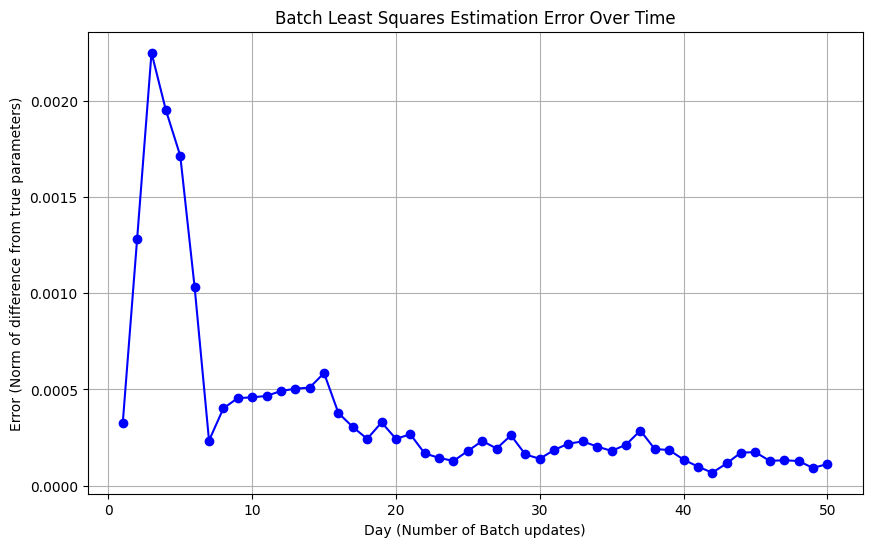

In [30]:
batch_ls_estimator = BatchedLeastSQ(lambda_=1.0) # Using lambda=1.0 for standard Batch LS

# Run Batch LS day by day
for day in range(1, num_days_to_simulate + 1):
    df_current_day = df_all_data[df_all_data['day'] == day]
    A_current_day, b_current_day, _ = construct_A_b(df_current_day) # `construct_A_b` returns correct A, b, param_names
    batch_ls_estimator.update_batch(A_current_day, b_current_day, true_params_vec)

# Display results
batch_estimates = batch_ls_estimator.get_estimate_history()
batch_errors = batch_ls_estimator.get_error_history()

print(f"Final Batch LS Estimates after {num_days_to_simulate} days (lambda={batch_ls_estimator.lambda_}):")
for i, param in enumerate(batch_ls_estimator.param_names):
    print(f"{param}: {batch_estimates[-1, i]:.4f}")

print("\nTrue Parameters:")
print(f"theta_1: {true_params_vec[0,0]:.4f}")
print(f"theta_2: {true_params_vec[1,0]:.4f}")

print(f"\nFinal Batch LS Estimation Error: {batch_errors[-1]:.4f}")

# Plotting the error convergence
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', color='blue')
plt.title('Batch Least Squares Estimation Error Over Time')
plt.xlabel('Day (Number of Batch updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.grid(True)
plt.show()

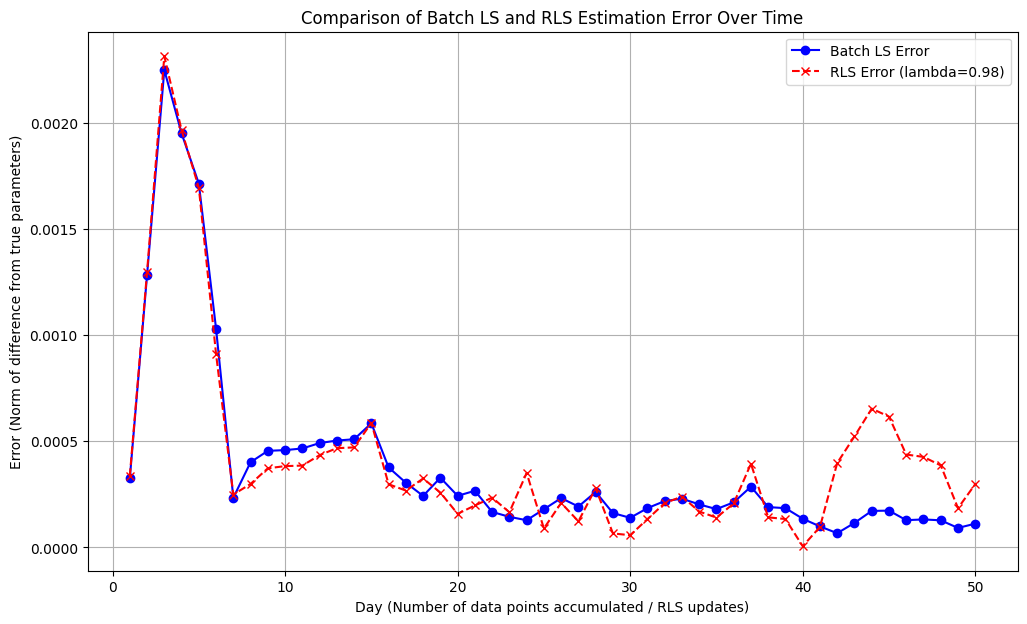

In [32]:
# Plotting Batch LS and RLS error convergence together
plt.figure(figsize=(12, 7))

plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

## Recursive Least Squares (RLS)

As we saw with Batch Least Squares, combining all past data improves estimation accuracy. However, continuously restacking and re-inverting large matrices can be computationally expensive and memory-intensive, especially as the amount of data grows indefinitely (e.g., in real-time applications).

**Recursive Least Squares (RLS)** provides an elegant solution to this problem. Instead of recalculating the entire estimate from scratch every time a new data point arrives, RLS updates the previous estimate using only the new observation. This 'recursive' nature makes it efficient for online processing and situations where parameters might slowly change over time.

The core idea behind RLS is to maintain an estimate of the inverse of the $\mathbf{A}^T\mathbf{A}$ matrix (often denoted as $\mathbf{P}$) and the $\mathbf{A}^T\mathbf{b}$ vector (often denoted as $\mathbf{q}$), and then update these recursively with each new measurement.

This method not only saves computational resources but also forms the foundation for more advanced filtering techniques like the Kalman Filter, which we can use when the parameters themselves are expected to change dynamically over time (e.g., if the runner's baseline performance is improving daily).

### Recursive Least Squares Math

Let's start by recalling the Batch LS solution written in terms of $\mathbf{S}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{A}_i$ and $\mathbf{q}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{b}_i$:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \mathbf{P}_K \mathbf{q}_K $$

Where $\mathbf{P}_K = \mathbf{S}_K^{-1}$.

When a new observation arrives at step $K+1$, consisting of $\mathbf{A}_{K+1}$ (a single row vector) and $\mathbf{b}_{K+1}$ (a single scalar), we can update $\mathbf{S}$ and $\mathbf{q}$ recursively:

$$ \mathbf{S}_{K+1} = \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

The challenge is to efficiently compute the new inverse $\mathbf{P}_{K+1} = \mathbf{S}_{K+1}^{-1}$ without re-inverting the entire matrix. This is where the **Woodbury Matrix Identity** (also known as the Sherman–Morrison–Woodbury formula) becomes incredibly useful:

For matrices $\mathbf{P}$, $\mathbf{H}$, and $\mathbf{R}$ where $\mathbf{P}^{-1}$ and $(\mathbf{R} + \mathbf{H} \mathbf{P} \mathbf{H}^T)^{-1}$ exist:

$$ (\mathbf{P} + \mathbf{H}^T \mathbf{R}^{-1} \mathbf{H})^{-1} = \mathbf{P}^{-1} - \mathbf{P}^{-1} \mathbf{H}^T (\mathbf{R} + \mathbf{H} \mathbf{P}^{-1} \mathbf{H}^T)^{-1} \mathbf{H} \mathbf{P}^{-1} $$

Applying this identity to find $\mathbf{P}_{K+1} = (\mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1}$, let:

*   $\mathbf{P} = \mathbf{S}_K^{-1} = \mathbf{P}_K$
*   $\mathbf{H}^T = \mathbf{A}_{K+1}^T$ (so $\mathbf{H} = \mathbf{A}_{K+1}$)
*   $\mathbf{R}^{-1} = \mathbf{I}$ (a $1 \times 1$ identity matrix, as $\mathbf{A}_{K+1}^T \mathbf{A}_{K+1}$ is a rank-1 update; essentially the scalar 1, representing the weighting of the new measurement contribution)

Then the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K $$

And finally, the update for the estimate $\hat{\mathbf{x}}_{K+1}$ is:

$$ \hat{\mathbf{x}}_{K+1} = \hat{\mathbf{x}}_K + \mathbf{K}_{K+1} (\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K) $$

Where $\mathbf{K}_{K+1}$ is the Kalman gain-like term for RLS:

$$ \mathbf{K}_{K+1} = \mathbf{P}_{K+1} \mathbf{A}_{K+1}^T = \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

This set of equations allows us to update our estimates iteratively, day by day, or run by run, without re-processing all historical data. The term $(\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K)$ represents the residual or innovation—the difference between the actual new measurement and what the current model predicted.

### Incorporating Forgetting Factor (Weighted RLS)

Often, in real-world scenarios, the true underlying parameters might not be constant but instead change slowly over time. For example, our runner's baseline performance might improve. To account for this, RLS can be extended with a **forgetting factor** ($\lambda$, where $0 < \lambda \le 1$).

The forgetting factor gives more weight to recent data and gradually 'forgets' older data. This is achieved by modifying the updates for $\mathbf{S}$ and $\mathbf{q}$:

$$ \mathbf{S}_{K+1} = \lambda \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \lambda \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

And consequently, the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = (\lambda \mathbf{P}_K^{-1} + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1} $$

Which, using the Woodbury identity, can be rewritten as:

$$ \mathbf{P}_{K+1} = \frac{1}{\lambda} \left( \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T \left(\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T\right)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K \right) $$

And the gain term:

$$ \mathbf{K}_{K+1} = \mathbf{P}_K \mathbf{A}_{K+1}^T (\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

If $\lambda=1$, this is standard RLS. If $\lambda < 1$, older data has less influence. A common practice is to initialize $\mathbf{P}_0$ with a large value (e.g., $10^3 \cdot \mathbf{I}$) to reflect high initial uncertainty in the parameters.

### RLS for Runner Timing Simulation

Now, we'll implement the RLS algorithm to track our runner's performance parameters. We will process the daily observations sequentially, updating our estimates each day. This will allow us to observe how the estimates evolve and converge over time, similar to batch LS, but with a more computationally efficient approach for streaming data.

We will use a forgetting factor ($\lambda$) to see how it affects the tracking of potentially changing parameters. For our current simulation, the true parameters are constant, so a $\lambda=1$ (no forgetting) should ideally yield results similar to batch LS as the number of days increases. However, if the runner's baseline was actually improving, a $\lambda < 1$ would be beneficial.

Let's apply the RLS to our simulated daily data.

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving and the parameters themselves are modeled dynamically.

In [27]:
class RecursiveLeastSQ:
    def __init__(self, lambda_=1.0, P0_diag=1e3, name='RecursiveLeastSQ_runner'):
        # lambda_: forgetting factor (0 < lambda_ <= 1)
        # P0_diag: initial diagonal value for P matrix (large value for high initial uncertainty)
        self.name = name
        self.lambda_ = lambda_

        # Model now has theta_1 and theta_2
        self.num_params = 2 # theta_1, theta_2
        self.param_names = ['theta_1', 'theta_2'] # Updated parameter names

        # Initialize P_k (inverse of S_k) with a large covariance to reflect high initial uncertainty
        self.P_k = P0_diag * np.eye(self.num_params)

        # Initialize x_k (parameter estimate) to zeros or a reasonable prior
        self.x_k = np.zeros((self.num_params, 1))

        self.estimates_history = []
        self.error_history = []

    def update(self, A_new, b_new, true_params):
        # A_new: single row (1 x num_params) or multiple rows (num_runs_day x num_params) for a given day
        # b_new: single value (1 x 1) or multiple values (num_runs_day x 1) for a given day

        # To process a day's worth of data as a 'batch' within one RLS step (effectively treating it as multiple sequential updates)
        # It's more common to process one observation at a time for true RLS, but for daily data, we can iterate.

        current_P = self.P_k.copy()
        current_x = self.x_k.copy()

        for i in range(A_new.shape[0]):
            A_i = A_new[i:i+1, :]
            b_i = b_new[i:i+1, :]

            # Calculate Kalman Gain-like term K_k+1
            # Denominator: (lambda * I + A_i * P_k * A_i.T)
            denominator = self.lambda_ * np.eye(A_i.shape[0]) + A_i @ current_P @ A_i.T
            K_k1 = current_P @ A_i.T @ np.linalg.inv(denominator)

            # Update parameter estimate x_k+1
            current_x = current_x + K_k1 @ (b_i - A_i @ current_x)

            # Update P_k+1
            current_P = (current_P - K_k1 @ A_i @ current_P) / self.lambda_

        # Store the updated state for the end of the day
        self.P_k = current_P
        self.x_k = current_x

        self.estimates_history.append(self.x_k)
        error = np.linalg.norm(self.x_k - true_params)
        self.error_history.append(error)

    def get_last_estimate(self):
        if self.estimates_history:
            return self.estimates_history[-1]
        return None

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)



Final RLS Estimates after 50 days (lambda=0.98):
theta_1: 0.1098
theta_2: 0.1002

True Parameters:
theta_1: 0.1100
theta_2: 0.1000

Final RLS Estimation Error: 0.0003


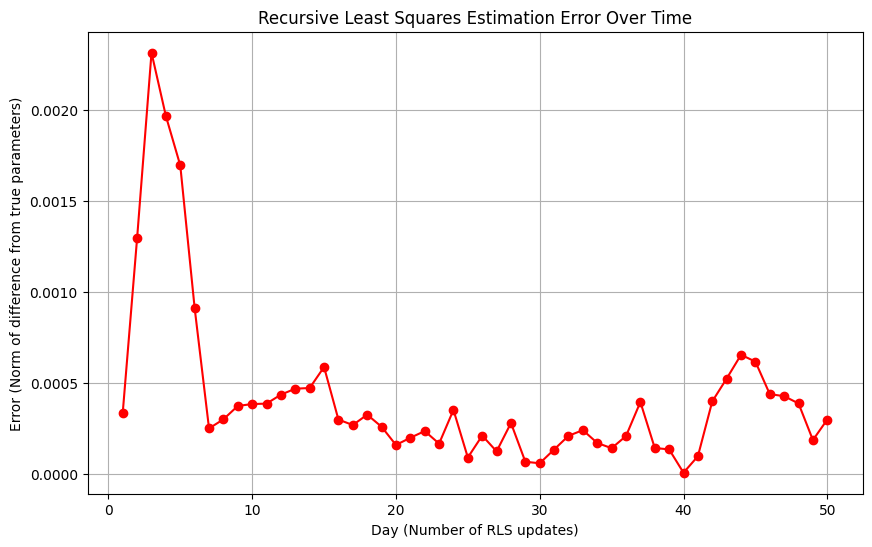

In [28]:

# --- Simulation and RLS Application ---

# true_params_vec is already correctly defined globally from the previous cell's update.
rls_estimator = RecursiveLeastSQ(lambda_=0.98, P0_diag=1e3) # Using a forgetting factor of 0.98

# Run RLS day by day
for day in range(1, num_days_to_simulate + 1):
    df_current_day = df_all_data[df_all_data['day'] == day]
    A_current_day, b_current_day, _ = construct_A_b(df_current_day) # `construct_A_b` returns correct A, b, param_names
    rls_estimator.update(A_current_day, b_current_day, true_params_vec)

# Display results
rls_estimates = rls_estimator.get_estimate_history()
rls_errors = rls_estimator.get_error_history()

print(f"\nFinal RLS Estimates after {num_days_to_simulate} days (lambda={rls_estimator.lambda_}):")
# Use the param_names from the RLS estimator to print results consistently
for i, param in enumerate(rls_estimator.param_names):
    print(f"{param}: {rls_estimates[-1, i]:.4f}")

print("\nTrue Parameters:")
print(f"theta_1: {true_params_vec[0,0]:.4f}")
print(f"theta_2: {true_params_vec[1,0]:.4f}")

print(f"\nFinal RLS Estimation Error: {rls_errors[-1]:.4f}")

# Plotting the error convergence
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='o', linestyle='-', color='red')
plt.title('Recursive Least Squares Estimation Error Over Time')
plt.xlabel('Day (Number of RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.grid(True)
plt.show()

### Comparing Batch LS and RLS Convergence

Let's plot the errors from both Batch LS and RLS on the same graph to visualize their convergence and performance.

We would expect both methods to converge to similar estimates for constant parameters as the amount of data increases, assuming an appropriate forgetting factor (like $\lambda=1$ or close to 1 for RLS). RLS might show a slightly different convergence path due to its sequential updating nature and the impact of the forgetting factor and initial conditions.

In [25]:
# Plotting Batch LS and RLS error convergence together
plt.figure(figsize=(12, 7))

plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'batch_errors' is not defined

<Figure size 1200x700 with 0 Axes>